In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, f1_score,
)
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "synthetic_safety_alert_data.csv"  # update if needed

df = pd.read_csv(DATA_PATH, parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

df["target"] = (df["Safety_Alert_Triggered"] == "Yes").astype(int)
df["hour"] = df["Timestamp"].dt.hour + df["Timestamp"].dt.minute / 60
df["day_of_week"] = df["Timestamp"].dt.dayofweek
df["day_of_month"] = df["Timestamp"].dt.day
df["month"] = df["Timestamp"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["night_operation"] = ((df["hour"] < 6) | (df["hour"] >= 21)).astype(int)

DROP_COLUMNS = ["Timestamp", "Safety_Alert_Triggered", "target", "Machine_ID", "Operator_ID"]
X = df.drop(columns=DROP_COLUMNS)
y = df["target"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['Shift_Type', 'Weather_Condition', 'Seatbelt_Status', 'Proximity_Hazard']
Numeric: ['Operator_Experience_Months', 'Engine_Hours', 'Fuel_Used_L', 'Load_Cycles', 'Load_Weight_tons', 'Max_Load_Capacity_tons', 'Load_Utilization_pct', 'Idling_Time_min', 'Operator_Shift_Hours', 'Continuous_Driving_min', 'Machine_Speed_kmph', 'Harsh_Braking_Events', 'Harsh_Acceleration_Events', 'Ground_Slope_deg', 'Machine_Tilt_deg', 'Visibility_m', 'Min_Obstacle_Distance_m', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'night_operation']


In [3]:
n = len(X)
train_end, val_end = int(n * 0.70), int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print("Train:", X_train.shape, "pos rate:", round(y_train.mean(), 3))
print("Val:  ", X_val.shape, "pos rate:", round(y_val.mean(), 3))
print("Test: ", X_test.shape, "pos rate:", round(y_test.mean(), 3))

Train: (10500, 27) pos rate: 0.279
Val:   (2250, 27) pos rate: 0.272
Test:  (2250, 27) pos rate: 0.292


In [4]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

In [5]:
candidates = {}

# --- CatBoost (native categorical handling) ---
cb = CatBoostClassifier(
    loss_function="Logloss", eval_metric="AUC", iterations=1500,
    learning_rate=0.04, depth=6, l2_leaf_reg=6, random_strength=1,
    auto_class_weights="Balanced", random_seed=42,
    od_type="Iter", od_wait=100, verbose=0, allow_writing_files=False,
)
cb.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_val, y_val), verbose=0)
candidates["CatBoost"] = ("native", cb)

# --- Logistic Regression ---
logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5)),
])
logreg_pipe.fit(X_train, y_train)
candidates["LogisticRegression"] = ("pipeline", logreg_pipe)

# --- XGBoost ---
xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", xgb.XGBClassifier(
        n_estimators=1500, learning_rate=0.04, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=6,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="auc", random_state=42,
    )),
])
xgb_pipe.fit(X_train, y_train)
candidates["XGBoost"] = ("pipeline", xgb_pipe)

# --- LightGBM ---
lgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", lgb.LGBMClassifier(
        n_estimators=1500, learning_rate=0.04, max_depth=6, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=6,
        class_weight="balanced", random_state=42, verbose=-1,
    )),
])
lgb_pipe.fit(X_train, y_train)
candidates["LightGBM"] = ("pipeline", lgb_pipe)

# --- Random Forest ---
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=500, max_depth=12, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1,
    )),
])
rf_pipe.fit(X_train, y_train)
candidates["RandomForest"] = ("pipeline", rf_pipe)


def get_proba(kind, model, X_):
    return model.predict_proba(X_)[:, 1]


val_results = {}
for name, (kind, model) in candidates.items():
    p = get_proba(kind, model, X_val)
    val_results[name] = (roc_auc_score(y_val, p), average_precision_score(y_val, p))

print(f"{'Model':<20}{'Val AUC':<12}{'Val PR-AUC':<12}")
for name, (auc, prauc) in sorted(val_results.items(), key=lambda x: -x[1][0]):
    print(f"{name:<20}{auc:<12.4f}{prauc:<12.4f}")

Model               Val AUC     Val PR-AUC  
LogisticRegression  0.9562      0.8947      
CatBoost            0.9537      0.8900      
XGBoost             0.9457      0.8672      
LightGBM            0.9449      0.8648      
RandomForest        0.9425      0.8536      


In [6]:
test_results = {}
for name, (kind, model) in candidates.items():
    p = get_proba(kind, model, X_test)
    test_results[name] = (roc_auc_score(y_test, p), average_precision_score(y_test, p))

print(f"{'Model':<20}{'Test AUC':<12}{'Test PR-AUC':<12}")
for name, (auc, prauc) in sorted(test_results.items(), key=lambda x: -x[1][0]):
    print(f"{name:<20}{auc:<12.4f}{prauc:<12.4f}")

best_model_name = max(test_results, key=lambda k: test_results[k][0])
print(f"\nBest model on test set: {best_model_name}")

Model               Test AUC    Test PR-AUC 
LogisticRegression  0.9502      0.8972      
CatBoost            0.9447      0.8863      
XGBoost             0.9397      0.8739      
LightGBM            0.9391      0.8705      
RandomForest        0.9295      0.8463      

Best model on test set: LogisticRegression


In [7]:
best_kind, best_model = candidates[best_model_name]
val_proba = get_proba(best_kind, best_model, X_val)
test_proba = get_proba(best_kind, best_model, X_test)

# Threshold selection on validation only (never on test)
thresholds = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[int(np.argmax(f1s))]
print(f"Selected decision threshold (max F1 on val): {best_threshold:.2f}")

test_pred = (test_proba >= best_threshold).astype(int)
print("\nTest classification report:")
print(classification_report(y_test, test_pred, target_names=["No Alert", "Alert"]))

print("Test AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, test_proba), 4))

Selected decision threshold (max F1 on val): 0.65

Test classification report:
              precision    recall  f1-score   support

    No Alert       0.91      0.92      0.91      1593
       Alert       0.80      0.78      0.79       657

    accuracy                           0.88      2250
   macro avg       0.85      0.85      0.85      2250
weighted avg       0.88      0.88      0.88      2250

Test AUC: 0.9502
Test PR-AUC: 0.8972


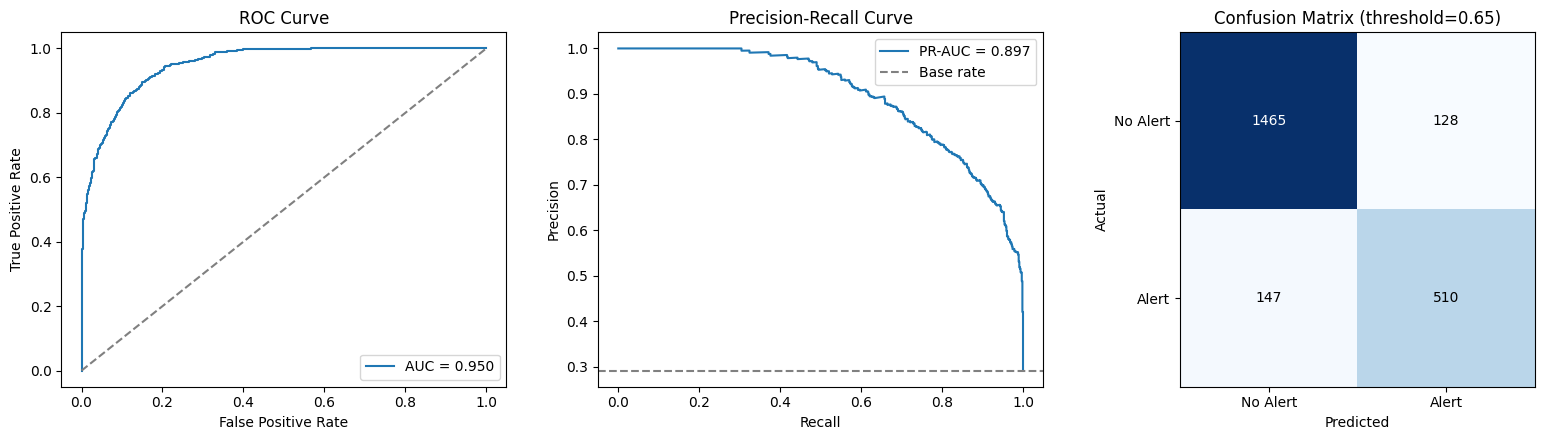

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, test_proba):.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Base rate")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["No Alert", "Alert"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["No Alert", "Alert"])
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
axes[2].set_title(f"Confusion Matrix (threshold={best_threshold:.2f})")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=120)
plt.show()

In [9]:
if best_model_name == "LogisticRegression":
    clf = best_model.named_steps["clf"]
    feature_names = best_model.named_steps["prep"].get_feature_names_out()
    coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
    print("Top drivers of Safety_Alert_Triggered (standardized logistic coefficients):")
    print(coefs.head(15))
elif best_model_name == "CatBoost":
    importances = pd.Series(best_model.get_feature_importance(), index=X.columns).sort_values(ascending=False)
    print("Top drivers of Safety_Alert_Triggered (CatBoost feature importance):")
    print(importances.head(15))
else:
    clf = best_model.named_steps["clf"]
    feature_names = best_model.named_steps["prep"].get_feature_names_out()
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(f"Top drivers of Safety_Alert_Triggered ({best_model_name} feature importance):")
    print(importances.head(15))

Top drivers of Safety_Alert_Triggered (standardized logistic coefficients):
num__Min_Obstacle_Distance_m        -1.569412
num__Harsh_Braking_Events            1.172558
cat__Seatbelt_Status_Fastened       -1.096231
cat__Seatbelt_Status_Unfastened      1.075935
num__Ground_Slope_deg                1.012644
cat__Proximity_Hazard_No            -1.003104
cat__Proximity_Hazard_Yes            0.982809
num__Continuous_Driving_min          0.949569
num__Harsh_Acceleration_Events       0.849590
num__Machine_Tilt_deg                0.772782
num__Visibility_m                   -0.695771
num__Operator_Shift_Hours            0.613177
num__Machine_Speed_kmph              0.494639
num__Operator_Experience_Months     -0.459846
cat__Weather_Condition_Heavy_Rain    0.267544
dtype: float64


In [10]:
if best_model_name == "CatBoost":
    best_model.save_model("best_model.cbm")
    print("Saved CatBoost model to best_model.cbm")
else:
    joblib.dump(best_model, "best_model.joblib")
    print(f"Saved {best_model_name} pipeline to best_model.joblib")

joblib.dump(best_threshold, "decision_threshold.joblib")

Saved LogisticRegression pipeline to best_model.joblib


['decision_threshold.joblib']

In [11]:
def predict_safety_alert(row_dict, model=best_model, kind=best_kind, threshold=best_threshold):
    """
    row_dict: a dict of raw feature values (same columns as X, pre-feature-engineering
    columns like Timestamp already expanded into hour/day_of_week/etc.)
    Returns: (probability, predicted_label)
    """
    row_df = pd.DataFrame([row_dict])[X.columns]
    proba = model.predict_proba(row_df)[:, 1][0]
    label = "Yes" if proba >= threshold else "No"
    return proba, label


# Example: pull one real row from the test set and predict it live
example = X_test.iloc[0].to_dict()
proba, label = predict_safety_alert(example)
print(f"Example prediction -> probability: {proba:.3f}, predicted alert: {label}, "
      f"actual: {'Yes' if y_test.iloc[0] == 1 else 'No'}")

Example prediction -> probability: 0.981, predicted alert: Yes, actual: Yes
